# XBTorch::Example 12:Retention & Drift

## Introduction

In many emerging memory technologies, programmed conductance values are not perfectly stable over time. Instead, devices may exhibit retention loss, conductance drift, and other forms of time-dependent behavior that gradually alter the physical state of the accelerator after deployment. These effects can lead to discrepancies between the conductances observed during inference and those originally programmed from the trained neural network.

To enable deployment-time reliability studies, XBTorch provides configurable retention and conductance drift models as part of its hardware-aware inference framework. These models operate directly on the programmed conductance state and can be combined with other inference-time nonidealities such as programming error, read noise, stuck-at defects, and limited DAC/ADC precision.

In this notebook, we demonstrate how to:

1. Configure retention and conductance drift parameters in an XBTorch inference accelerator.
2. Evaluate the effect of increasing retention time on inference accuracy.
3. Evaluate the effect of different drift coefficients on inference accuracy.
4. Study deployment-time degradation using realistic, time-evolving conductance states.

Throughout these experiments, the neural network weights remain unchanged; only the underlying hardware realization evolves according to the specified retention model. This allows us to isolate and study the impact of time-dependent conductance evolution on inference robustness.

## Getting Started

Let's import necessary dependencies.

In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import pickle
from pathlib import Path

import torch
import torch.nn as nn

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset

from functools import partial
import torch.optim as optim

In [2]:
# XBTorch imports
import xbtorch

from xbtorch.patches import xbtorch_model

from xbtorch.nn.utils import test_classifier

from xbtorch.deployment import SimpleFixedPoint, map_random, encode_simple_binary, encode_MAO, encode_LEA1, encode_LEA2, compute_error

from nets.mlp import SimpleMLP

W0604 19:19:33.322000 2608752 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W0604 19:19:33.322000 2608752 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.
/mnt/osama.yousuf1/xbtorch/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Let's fix the seed for reproducibility, and initialize network and XBTorch-specific parameters.

In [3]:
seed = 0

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed) # controls weight updatejump table stochasticity

# Check if CUDA is available and select the device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


## Initialize XBTorch

Like last time, let's initialize the XBTorch library.

In [4]:
xb_size = (2500, 2500)
g_min = 133
g_max = 233
read_noise = 0.0
write_noise = 0.0
weight_encoding_scheme = encode_simple_binary
mapping_scheme = map_random
output_polling_mode = "avg"
adc_precision = dac_precision = 8
stateful = False
input_encoding_scheme = "instant"

# Parameters not previously shown.
retention_time=10
drift_coefficient=0.05
drift_t0=0.5
drift_variation=0.5

In the cell above, we initialize various XBTorch parameters pertaining to hardware-aware inference. The newly introduced retention and drift parameters are summarized below:

| Parameter | Purpose |
|------------|----------|
| `retention_time` | Elapsed deployment time of the network on the accelerator |
| `drift_coefficient` | Nominal value of the drift coefficient, $\nu$ |
| `drift_t0` | Reference time constant, $t_0$ |
| `drift_variation` | Device-to-device variation in $\nu$. If set to `0.0`, all devices experience identical deterministic drift. |

XBTorch models retention-induced conductance evolution using a power-law drift model similar to that employed in NeuroSim:

$$
G(t) = G_0 \left(\frac{t}{t_0}\right)^{-\nu}
$$

where:

- $G_0$ is the programmed conductance,
- $G(t)$ is the conductance after retention time $t$,
- $t_0$ is a reference time constant,
- $\nu$ is the drift coefficient.

When `drift_variation > 0`, each device samples its own value of $\nu$, allowing heterogeneous drift behavior across the crossbar array. Larger values of `retention_time` or `drift_coefficient` generally produce larger deviations from the originally programmed conductance state.

For more details on the API and available inference accelerators, see the full XBTorch documentation.

In [5]:
inference_accelerator = SimpleFixedPoint(g_min=g_min, 
                                         g_max=g_max, 
                                         adc_bits=adc_precision, 
                                         dac_bits=dac_precision, 
                                         read_noise=read_noise, 
                                         write_noise=write_noise, 
                                         xb_size=xb_size,
                                         weight_encoding_scheme=weight_encoding_scheme, 
                                         input_encoding_scheme=input_encoding_scheme,
                                         xb_mapping_scheme=mapping_scheme,
                                         stateful=stateful,
                                         retention_time=retention_time,
                                         drift_coefficient=drift_coefficient,
                                         drift_t0=drift_t0,
                                         drift_variation=drift_variation,
                                         device=device)

We can now initialize XBTorch. Recall that if a parameter is not provided, default values are utilized. The reader is directed to `XBParams.__init__()` for the underlying implementation.

In [6]:
wage_params = { "wl_weight": 2, # 2 = ternary weights
                "wl_grad": 8,
                "wl_activation": 8,
                "wl_error": 8,
                "rounding_weight" : "nearest",
                "rounding_activation" : "nearest",
                "rounding_grad" : "nearest",
                "rounding_error" : "nearest",
               }

# Init xbtorch
xbtorch.initialize(pytorch_device=device,
                   inference_accelerator=inference_accelerator,
                   wage_quantize=True, # since the trained solution utilized wage quantization
                   wage_params=wage_params
                   )

## Prepare the dataset

We can now prepare the dataset for our neural network.

In [7]:
# Define transforms to apply to the data
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize the image data
])

# Load the MNIST training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders for batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=4096, shuffle=True, generator=torch.Generator(), num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=10000, shuffle=False, generator=torch.Generator(), num_workers=4)

## Prepare the model

We simply instantiate and load the state dictionary of our HWA pre-trained simple 2-layer perceptron network. 

In [8]:
# Define the model
input_size = 28 * 28
hidden_size = 150
output_size = 10

# Create Model
model = SimpleMLP(input_size, hidden_size, output_size).to(device)
model = xbtorch_model(model)

# Override state dict. 
# If we had dumped the final state_dict directly, model.load_state_dict(torch.load(..)) could be used instead
with open("checkpoints/hwa_train_mlp_hwa_example.pkl", "rb") as f:
    full_weights_hwa = pickle.load(f)
    
epoch = -1 # load last epoch's weights

for name, param in model.named_parameters():
    new_tensor = torch.from_numpy(full_weights_hwa[name][epoch, ...]).to(
        device=param.device,
        dtype=param.dtype,
    )
    param.data = new_tensor

## Baseline performance

We can firstly compute the baseline test accuracy of our network. This is the accuracy before activating the inference accelerator (i.e. all computations of the network happen without the accelerator primitive's intervention).

In [9]:
baseline_acc, _ = test_classifier(test_loader, model, device)

print(baseline_acc)

89.7


## Retention Time Sweep

We first investigate the effect of deployment time on inference accuracy.

In this experiment, the drift coefficient is held constant while the retention time is varied over several orders of magnitude. As retention time increases, the programmed conductance values drift farther from their original states, resulting in increasing mismatch between the trained network parameters and the realized hardware conductances.

For each retention time, inference is repeated multiple times to capture variability introduced by stochastic drift behavior.

In [10]:
iterations = 10

retention_times = np.logspace(
    np.log10(0.5),
    np.log10(100),
    10
)

model.xb_eval()

ret_time_sweep_accs = np.zeros((len(retention_times), iterations))

for j, ret_time in enumerate(retention_times):
    inference_accelerator.retention_time = ret_time
    for i in range(iterations):    
        acc, _ = test_classifier(test_loader, model, device)
        ret_time_sweep_accs[j, i] = acc

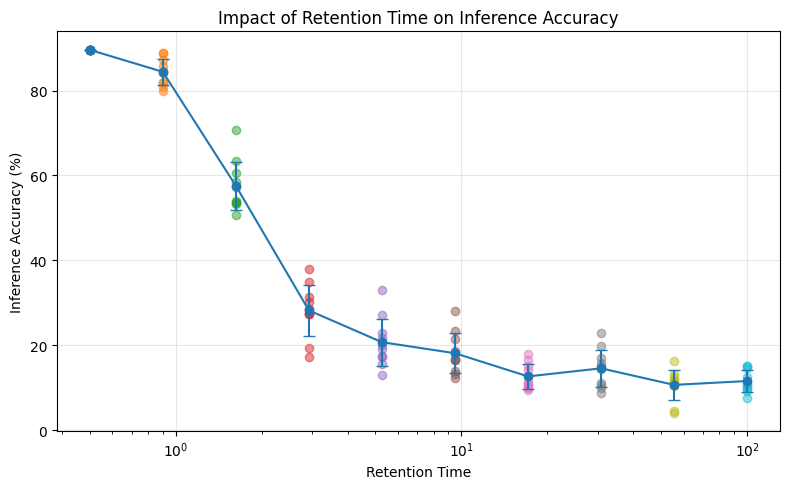

In [11]:
# Let's visualize results

import numpy as np
import matplotlib.pyplot as plt

means = np.mean(ret_time_sweep_accs, axis=1)
stds = np.std(ret_time_sweep_accs, axis=1)

plt.figure(figsize=(8,5))

plt.errorbar(
    retention_times,
    means,
    yerr=stds,
    marker='o',
    capsize=4
)

for i, t in enumerate(retention_times):
    plt.scatter(
        np.full(ret_time_sweep_accs.shape[1], t),
        ret_time_sweep_accs[i],
        alpha=0.5
    )

plt.xscale('log')
plt.xlabel("Retention Time")
plt.ylabel("Inference Accuracy (%)")
plt.title("Impact of Retention Time on Inference Accuracy")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The figure above shows inference accuracy as a function of retention time.

As expected, increasing retention time causes larger deviations from the originally programmed conductance values, which in turn degrades inference accuracy. The precise degradation trend depends on both the drift model parameters and the network's inherent robustness to hardware perturbations.

This experiment demonstrates that XBTorch can capture deployment-time accuracy degradation arising from long-term conductance evolution.

## Drift Coefficient Sweep

Next, we hold retention time fixed and vary the drift coefficient $\nu$.

The drift coefficient controls the rate at which conductance evolves over time. Larger values correspond to more severe retention-induced drift and therefore larger deviations from the originally programmed device state.

This experiment isolates the impact of device technology characteristics from deployment duration.

In [12]:
drift_coefficients = [0.0, 0.1, 0.25, 0.5, 1.0, 1.5, 2.0]
retention_time = retention_times[1]
inference_accelerator.retention_time = retention_time

drift_coeff_sweep_accs = np.zeros((len(drift_coefficients), iterations))

for j, drift_coeff in enumerate(drift_coefficients):
    inference_accelerator.drift_coefficient = drift_coeff
    for i in range(iterations):
        acc, _ = test_classifier(test_loader, model, device)
        drift_coeff_sweep_accs[j, i] = acc

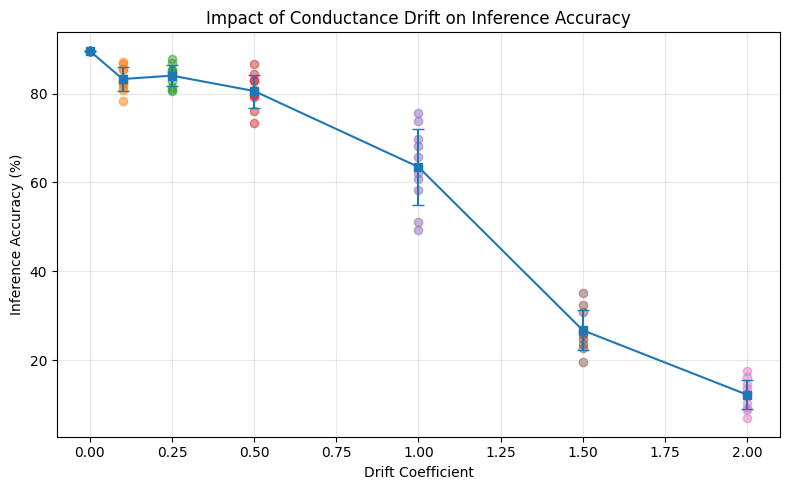

In [13]:
# Let's visualize again

means = np.mean(drift_coeff_sweep_accs, axis=1)
stds = np.std(drift_coeff_sweep_accs, axis=1)

plt.figure(figsize=(8,5))

plt.errorbar(
    drift_coefficients,
    means,
    yerr=stds,
    marker='s',
    capsize=4
)

for i, coeff in enumerate(drift_coefficients):
    plt.scatter(
        np.full(drift_coeff_sweep_accs.shape[1], coeff),
        drift_coeff_sweep_accs[i],
        alpha=0.5
    )

plt.xlabel("Drift Coefficient")
plt.ylabel("Inference Accuracy (%)")
plt.title("Impact of Conductance Drift on Inference Accuracy")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The figure above illustrates the sensitivity of inference accuracy to the drift coefficient.

For a fixed deployment time, larger drift coefficients produce more aggressive conductance evolution and generally lead to larger accuracy degradation. Conversely, technologies exhibiting smaller drift coefficients maintain conductance stability for longer periods and therefore preserve inference accuracy more effectively.

Together with the retention-time sweep, this experiment demonstrates how XBTorch can be used to study both deployment-time effects and technology-dependent retention characteristics.

## Conclusion

In this notebook, we demonstrated XBTorch's retention and conductance drift modeling capabilities for hardware-aware inference.

Using a power-law conductance evolution model, we examined two key dimensions of deployment-time reliability:

1. **Retention Time** — representing how long a network remains deployed on hardware before evaluation.
2. **Drift Coefficient** — representing the intrinsic retention characteristics of the underlying memory technology.

The experiments show that both parameters can materially impact inference accuracy by perturbing the programmed conductance state over time. Furthermore, because XBTorch supports device-to-device drift variability through `drift_variation`, users can investigate both deterministic and heterogeneous conductance evolution scenarios.

Importantly, retention and drift are modeled independently from other inference-time nonidealities such as programming error and read noise. This allows users to isolate individual error mechanisms or study their combined effects within a unified hardware-aware inference framework.

The implementation provided here is intentionally lightweight and extensible. Alternative drift formulations, technology-specific retention models, and additional time-dependent nonidealities can be incorporated by extending the inference accelerator interface, enabling rapid exploration of deployment-time reliability across emerging memory technologies.